Name: Dip Bhattacharjee
Email: dipjee678@gmail.com

# Question 1

In [87]:
import pandas as pd
df = pd.read_csv("titanic_data_updated.csv")

print("Dataset Shape:")
print(df.shape)

print("First 10 Rows:")
print(df.head(10))

print("5 Random Samples:")
print(df.sample(5))

Dataset Shape:
(891, 12)
First 10 Rows:
   PassengerId Survived  Pclass  \
0            1       no   third   
1            2      yes   first   
2            3      yes   third   
3            4      yes   first   
4            5       no   third   
5            6       no   third   
6            7       no   first   
7            8       no   third   
8            9      yes   third   
9           10      yes  second   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   
5                                   Moran, Mr. James    male   NaN      0   
6                            McCart

# Question 2


In [88]:
print("Total Missing Values in Each Column:")
print(df.isnull().sum())

print("Total Duplicate Rows:",df.duplicated().sum())

df.drop_duplicates(inplace=True)


Total Missing Values in Each Column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
Total Duplicate Rows: 0


# Question 3


In [89]:
print("Dataset Information:\n")
print(df.info())

print("\nStatistical Summary:\n")
print(df.describe())

print("\n")
print("2 Observations:")
print("1: The average passenger age is around 29.7 years, so most passengers were adults.")
print("2: The Age column has only 714 non-null values out of 891.")


Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    object 
 2   Pclass       891 non-null    object 
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(3), object(7)
memory usage: 83.7+ KB
None

Statistical Summary:

       PassengerId         Age       SibSp       Parch        Fare
count   891.000000  714.000000  891.000000  891.000000  891.000000
mean    446.000000   29.699118    0.523008    0.381594   32.

# Question 4

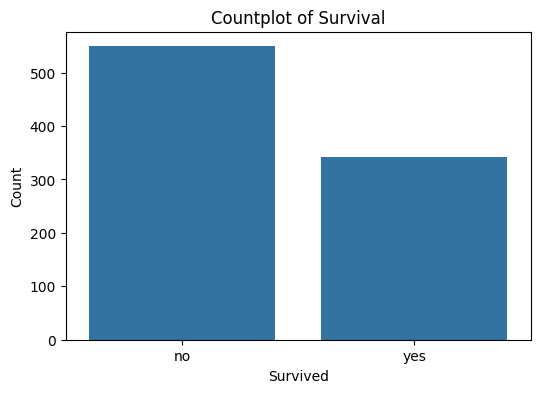


Percentage Distribution:

Survived
no     61.616162
yes    38.383838
Name: count, dtype: float64




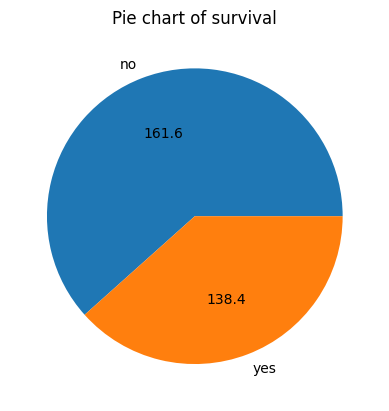

2 Insights:
1: The percentage distribution shows that about 61.6% passengers did not survive, while only about 38.4% passengers survived.
2: The countplot shows that the number of passengers marked as no is much higher than yes.


In [90]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(data = df,x = df['Survived'])

plt.title("Countplot of Survival")
plt.xlabel("Survived")
plt.ylabel("Count")
plt.show()


percentage = (df['Survived'].value_counts()/len(df))*100
print("\nPercentage Distribution:\n")
print(percentage)
print("\n")


survived_count = df['Survived'].value_counts()
survived_label = df['Survived'].unique()
plt.pie(survived_count,labels=survived_label,autopct="1%.1f")

plt.title("Pie chart of survival")
plt.show()

print("2 Insights:")
print("1: The percentage distribution shows that about 61.6% passengers did not survive, while only about 38.4% passengers survived.")
print("2: The countplot shows that the number of passengers marked as no is much higher than yes.")


# Question 5


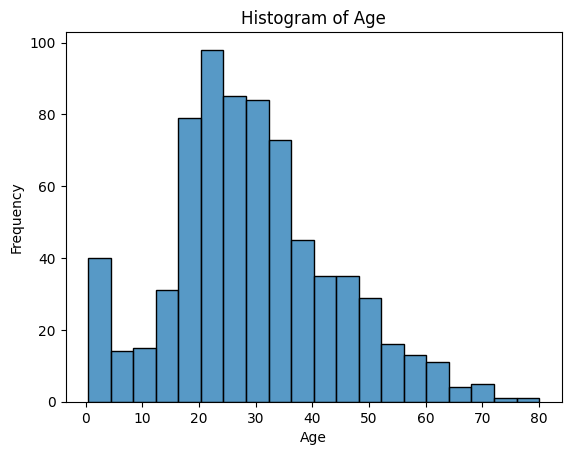

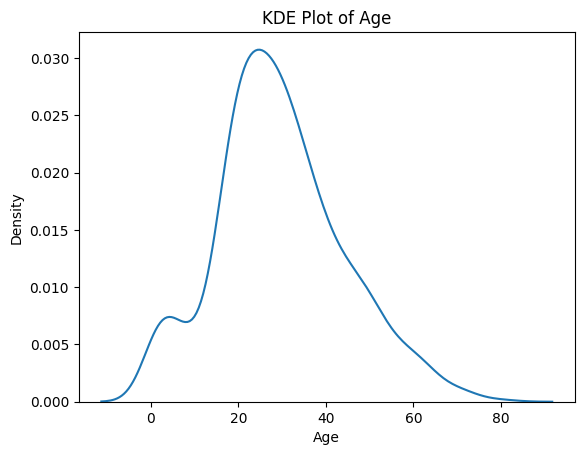



2 Observations:
1: The histogram shows that most passengers were between 20 and 35 years old.
2: The KDE plot indicates that the age distribution is right-skewed.


In [91]:
sns.histplot(df['Age'], bins=20)
plt.title("Histogram of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()


sns.kdeplot(df['Age'],)
plt.title("KDE Plot of Age")
plt.xlabel("Age")
plt.show()


print("\n")
print("2 Observations:")
print("1: The histogram shows that most passengers were between 20 and 35 years old.")
print("2: The KDE plot indicates that the age distribution is right-skewed.")


# Question 6

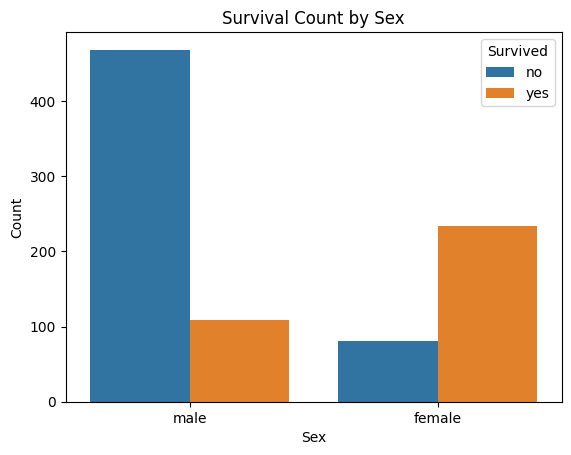

Normalized Survival Ratios (%):
Sex     Survived
female  yes         0.742038
        no          0.257962
male    no          0.811092
        yes         0.188908
Name: proportion, dtype: float64


2 Insights:
1: Female passengers had a significantly higher survival rate than male passengers.
2: The countplot shows a very high number of male non-survivors compared to survivors.


In [92]:
sns.countplot( data=df,x=df['Sex'],hue=df['Survived'])
plt.title("Survival Count by Sex")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.show()

print("Normalized Survival Ratios (%):")
survival_ratio = df.groupby('Sex')['Survived'].value_counts(normalize=True)
print(survival_ratio)

print("\n")
print("2 Insights:")
print("1: Female passengers had a significantly higher survival rate than male passengers.")
print("2: The countplot shows a very high number of male non-survivors compared to survivors.")

# Question 7

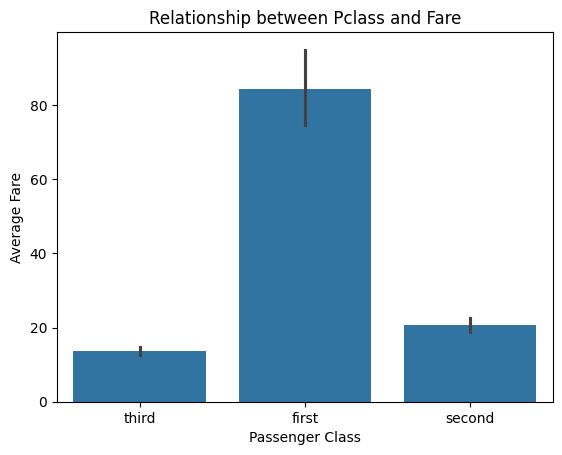



2 Observations:
1: First-class passengers paid the highest average fare,which is around 84.
2: Third-class passengers paid the lowest average fare, approximately 14.


In [93]:
sns.barplot(data=df,x=df['Pclass'],y = df['Fare'])
plt.title("Relationship between Pclass and Fare")
plt.xlabel("Passenger Class")
plt.ylabel("Average Fare")
plt.show()


print("\n")
print("2 Observations:")
print("1: First-class passengers paid the highest average fare,which is around 84.")
print("2: Third-class passengers paid the lowest average fare, approximately 14.")


# Question 8

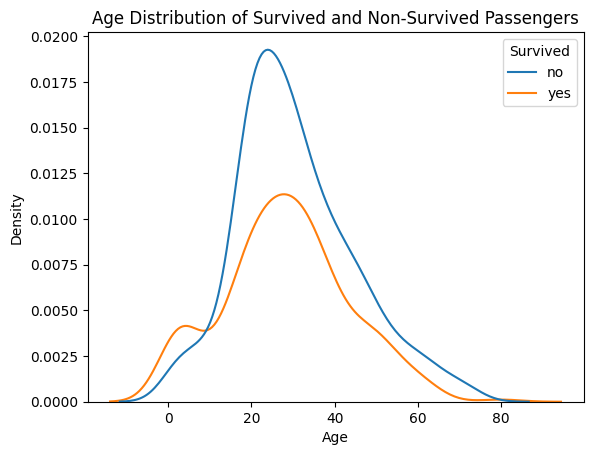



2 Insights:
1: Both survivors and non-survivors were mostly between 20 and 40 years old
2: The density of non-survivors is higher than survivors, indicating that more passengers in this age group did not survive.


In [94]:
sns.kdeplot(data=df,x=df['Age'],hue=df['Survived'])
plt.title("Age Distribution of Survived and Non-Survived Passengers")
plt.xlabel("Age")
plt.ylabel("Density")
plt.show()

print("\n")
print("2 Insights:")
print("1: Both survivors and non-survivors were mostly between 20 and 40 years old")
print("2: The density of non-survivors is higher than survivors, indicating that more passengers in this age group did not survive.")

# Quuestion 9

In [95]:
from sklearn.model_selection import train_test_split

df = df.drop(['PassengerId', 'Name', 'Ticket'], axis=1)

X = df.drop('Survived', axis=1)
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test :", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test :", y_test.shape)


Shape of X_train: (712, 8)
Shape of X_test : (179, 8)
Shape of y_train: (712,)
Shape of y_test : (179,)


# Quuestion 10

In [96]:
from sklearn.impute import SimpleImputer

age_imputer = SimpleImputer(strategy='mean')
df['Age'] = age_imputer.fit_transform(df[['Age']])


embarked_imputer = SimpleImputer(strategy='most_frequent')
df['Embarked'] = embarked_imputer.fit_transform(df[['Embarked']]).ravel()


cabin_imputer = SimpleImputer(strategy='constant',fill_value='Missing')
df['Cabin'] = cabin_imputer.fit_transform(df[['Cabin']]).ravel()


print("Missing Values:")

print(df.isnull().sum())

Missing Values:
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Cabin       0
Embarked    0
dtype: int64
